# Relax Take-Home: User Adoption Analysis

This notebook identifies **adopted users** using the prompt definition:

> A user is adopted if they logged into the product on **three separate days in at least one seven-day period**.

It then evaluates which signup-time factors best predict future adoption.

Files expected in the same folder as this notebook:
- `takehome_users(1).csv`
- `takehome_user_engagement(1).csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.formula.api as smf
from pathlib import Path

BASE = Path.cwd()

USERS_CSV = BASE / "takehome_users.csv"
ENGAGEMENT_CSV = BASE / "takehome_user_engagement.csv"

OUT = BASE / "outputs"
OUT.mkdir(exist_ok=True)

## 1) Load data

In [2]:
users = pd.read_csv(USERS_CSV, encoding="latin1")
engagement = pd.read_csv(ENGAGEMENT_CSV)

users["creation_time"] = pd.to_datetime(users["creation_time"])
engagement["time_stamp"] = pd.to_datetime(engagement["time_stamp"])
engagement["date"] = engagement["time_stamp"].dt.normalize()

print("Users shape:", users.shape)
print("Engagement shape:", engagement.shape)

users.head()

Users shape: (12000, 10)
Engagement shape: (207917, 4)


,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


## 2) Build the adopted-user target

Definition used:
- count distinct login days per user
- mark the user adopted if any 7-day window contains at least 3 distinct login days


In [3]:
daily = (
    engagement.drop_duplicates(["user_id", "date"])
    .sort_values(["user_id", "date"])
)

def is_adopted(dates: pd.Series) -> bool:
    arr = dates.values.astype("datetime64[D]")
    if len(arr) < 3:
        return False
    return np.any((arr[2:] - arr[:-2]).astype("timedelta64[D]").astype(int) <= 6)

adopted = daily.groupby("user_id")["date"].apply(is_adopted)

users["adopted"] = users["object_id"].map(adopted).fillna(False).astype(int)
users["adopted"].value_counts().rename(index={0: "not adopted", 1: "adopted"})

C:\Users\27025\AppData\Local\Temp\ipykernel_38644\2283935590.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  users["adopted"] = users["object_id"].map(adopted).fillna(False).astype(int)


adopted
not adopted    10398
adopted         1602
Name: count, dtype: int64

In [4]:
adoption_rate = users["adopted"].mean()
adopted_users = int(users["adopted"].sum())
total_users = len(users)

print(f"Adopted users: {adopted_users:,} / {total_users:,}")
print(f"Adoption rate: {adoption_rate:.1%}")

Adopted users: 1,602 / 12,000
Adoption rate: 13.4%


## 3) Engineer signup-time features

Only features plausibly available at or near signup are kept for the main analysis.
`last_session_creation_time` is intentionally excluded from the predictive model because it leaks later user behavior.


In [5]:
users["email_domain"] = users["email"].str.split("@").str[-1].str.lower()
users["personal_email"] = users["email_domain"].isin(
    {"gmail.com", "yahoo.com", "hotmail.com"}
).astype(int)

users["org_size"] = users.groupby("org_id")["object_id"].transform("count")
users["log_org_size"] = np.log1p(users["org_size"])
users["signup_quarter"] = users["creation_time"].dt.to_period("Q").astype(str)

max_obs_date = engagement["time_stamp"].max().normalize()
users["days_observed"] = (max_obs_date - users["creation_time"].dt.normalize()).dt.days

users[[
    "object_id", "creation_source", "org_size", "personal_email",
    "opted_in_to_mailing_list", "enabled_for_marketing_drip",
    "signup_quarter", "days_observed", "adopted"
]].head()

,object_id,creation_source,org_size,personal_email,opted_in_to_mailing_list,enabled_for_marketing_drip,signup_quarter,days_observed,adopted
0,1,GUEST_INVITE,75,1,1,0,2014Q2,45,0
1,2,ORG_INVITE,233,0,0,0,2013Q4,203,1
2,3,ORG_INVITE,32,0,0,0,2013Q1,444,0
3,4,GUEST_INVITE,233,1,0,0,2013Q2,381,0
4,5,GUEST_INVITE,16,1,0,0,2013Q1,505,0


## 4) Summary tables

In [6]:
overall = pd.DataFrame(
    {
        "metric": [
            "users",
            "adopted_users",
            "adoption_rate",
            "min_days_observed",
            "median_days_observed",
        ],
        "value": [
            len(users),
            int(users["adopted"].sum()),
            users["adopted"].mean(),
            int(users["days_observed"].min()),
            float(users["days_observed"].median()),
        ],
    }
)
overall.to_csv(OUT / "overall_metrics.csv", index=False)
overall

,metric,value
0,users,12000.0000
1,adopted_users,1602.0000
2,adoption_rate,0.1335
3,min_days_observed,7.0000
4,median_days_observed,305.0000


In [7]:
source_summary = (
    users.groupby("creation_source")["adopted"]
    .agg(["mean", "sum", "count"])
    .sort_values("mean", ascending=False)
    .rename(columns={"mean": "adoption_rate", "sum": "adopted_users", "count": "users"})
)
source_summary.to_csv(OUT / "adoption_by_creation_source.csv")
source_summary

,adoption_rate,adopted_users,users
creation_source,,,
SIGNUP_GOOGLE_AUTH,0.167509,232,1385
GUEST_INVITE,0.166436,360,2163
SIGNUP,0.140393,293,2087
ORG_INVITE,0.129995,553,4254
PERSONAL_PROJECTS,0.077688,164,2111


In [8]:
users["org_size_quintile"] = pd.qcut(users["org_size"], 5, duplicates="drop")
org_summary = (
    users.groupby("org_size_quintile", observed=False)["adopted"]
    .agg(["mean", "sum", "count"])
    .rename(columns={"mean": "adoption_rate", "sum": "adopted_users", "count": "users"})
)
org_summary.to_csv(OUT / "adoption_by_org_size_quintile.csv")
org_summary

,adoption_rate,adopted_users,users
org_size_quintile,,,
"(1.999, 19.0]",0.168256,441,2621
"(19.0, 25.0]",0.138718,316,2278
"(25.0, 38.0]",0.147257,349,2370
"(38.0, 64.0]",0.124520,292,2345
"(64.0, 319.0]",0.085499,204,2386


## 5) Logistic regression

This is a simple interpretable model using signup-available features.
The coefficients table includes odds ratios for easier interpretation.


In [9]:
formula = (
    "adopted ~ C(creation_source) + opted_in_to_mailing_list + "
    "enabled_for_marketing_drip + log_org_size + C(signup_quarter) + personal_email"
)

model = smf.logit(formula, data=users).fit(disp=False)
coef = model.summary2().tables[1].copy()
coef["odds_ratio"] = np.exp(coef["Coef."])
coef.to_csv(OUT / "logistic_regression_coefficients.csv")
coef.sort_values("odds_ratio", ascending=False)

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975],odds_ratio
personal_email,0.099834,0.059361,1.681817,9.260434e-02,-0.016511,0.216178,1.104987
opted_in_to_mailing_list,0.050601,0.071559,0.707128,4.794871e-01,-0.089651,0.190854,1.051903
Intercept,0.019667,0.198766,0.098946,9.211812e-01,-0.369907,0.409241,1.019862
enabled_for_marketing_drip,0.008700,0.086894,0.100117,9.202511e-01,-0.161610,0.179009,1.008738
C(creation_source)[T.SIGNUP_GOOGLE_AUTH],-0.024399,0.097430,-0.250426,8.022575e-01,-0.215359,0.166561,0.975896
C(signup_quarter)[T.2012Q3],-0.069370,0.153583,-0.451679,6.515003e-01,-0.370387,0.231647,0.932981
C(signup_quarter)[T.2013Q4],-0.103992,0.148660,-0.699529,4.842214e-01,-0.395359,0.187376,0.901233
C(signup_quarter)[T.2012Q4],-0.111985,0.153449,-0.729786,4.655211e-01,-0.412738,0.188769,0.894058
C(signup_quarter)[T.2013Q2],-0.151310,0.152042,-0.995188,3.196449e-01,-0.449306,0.146686,0.859581
C(signup_quarter)[T.2013Q1],-0.177778,0.152800,-1.163472,2.446381e-01,-0.477260,0.121704,0.837128


In [12]:
# Keep only users with at least 60 observed days
users_60 = users[users["days_observed"] >= 60].copy()

stable_model = smf.logit(formula, data=users_60).fit(disp=False)
stable_coef = stable_model.summary2().tables[1].copy()
stable_coef["odds_ratio"] = np.exp(stable_coef["Coef."])
stable_coef.to_csv(OUT / "logistic_regression_coefficients_60d_subset.csv")

stable_coef.sort_values("odds_ratio", ascending=False).head(10)

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975],odds_ratio
personal_email,0.081775,0.060312,1.355875,0.175139,-0.036434,0.199984,1.085212
enabled_for_marketing_drip,0.043025,0.088056,0.488607,0.625120,-0.129562,0.215611,1.043964
Intercept,0.034288,0.200684,0.170853,0.864339,-0.359046,0.427621,1.034882
opted_in_to_mailing_list,0.034146,0.072974,0.467920,0.639842,-0.108881,0.177173,1.034736
C(creation_source)[T.SIGNUP_GOOGLE_AUTH],-0.010812,0.099333,-0.108843,0.913327,-0.205501,0.183878,0.989247
C(signup_quarter)[T.2012Q3],-0.068880,0.153578,-0.448504,0.653790,-0.369888,0.232127,0.933438
C(signup_quarter)[T.2013Q4],-0.103170,0.148656,-0.694018,0.487671,-0.394531,0.188191,0.901974
C(signup_quarter)[T.2012Q4],-0.111652,0.153446,-0.727632,0.466839,-0.412400,0.189096,0.894355
C(signup_quarter)[T.2013Q2],-0.149809,0.152037,-0.985348,0.324453,-0.447796,0.148177,0.860872
C(signup_quarter)[T.2013Q1],-0.176638,0.152796,-1.156038,0.247665,-0.476114,0.122837,0.838083


## 6) Visuals

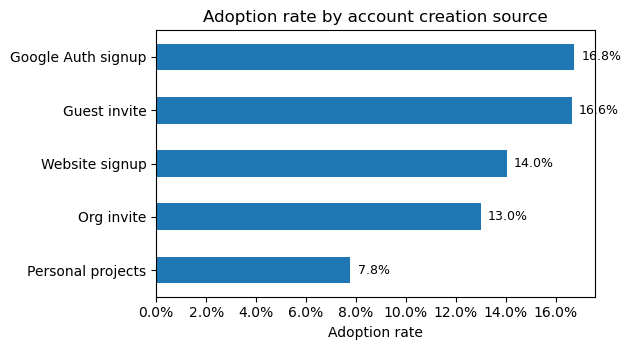

In [13]:
source_label_map = {
    "SIGNUP_GOOGLE_AUTH": "Google Auth signup",
    "GUEST_INVITE": "Guest invite",
    "SIGNUP": "Website signup",
    "ORG_INVITE": "Org invite",
    "PERSONAL_PROJECTS": "Personal projects",
}

plot_source = source_summary["adoption_rate"].rename(index=source_label_map).sort_values()

plt.figure(figsize=(6.4, 3.6))
ax = plot_source.plot(kind="barh")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Adoption rate")
ax.set_ylabel("")
ax.set_title("Adoption rate by account creation source")

for i, v in enumerate(plot_source.values):
    ax.text(v + 0.003, i, f"{v:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT / "adoption_by_source.png", dpi=200, bbox_inches="tight")
plt.show()

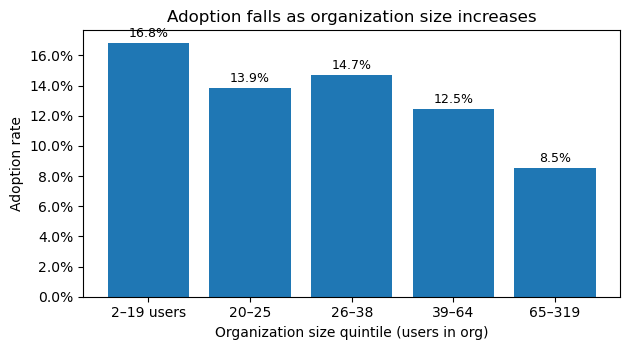

In [14]:
plot_org = org_summary["adoption_rate"]
labels = ["2–19 users", "20–25", "26–38", "39–64", "65–319"]

plt.figure(figsize=(6.4, 3.6))
plt.bar(labels, plot_org.values)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylabel("Adoption rate")
plt.xlabel("Organization size quintile (users in org)")
plt.title("Adoption falls as organization size increases")

for i, v in enumerate(plot_org.values):
    plt.text(i, v + 0.004, f"{v:.1%}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT / "adoption_by_org_size.png", dpi=200, bbox_inches="tight")
plt.show()